In [3]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
DATA_PATH = Path(
    "../data/processed/audio_features.csv"
)

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(240, 44)


,rms_mean,rms_std,zcr_mean,zcr_std,centroid_mean,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,...,mfcc_13_mean,mfcc_13_std,item,condition,method,process,score_mean,score_std,score_median,n_ratings
0,0.031402,0.035702,0.037500,0.034218,974.761973,543.516470,810.748935,232.394348,1804.392492,822.144230,...,2.051651,9.129880,DE_CosmosLandromat_remix1_LD6,LP3.5,DE,LP35,19.230769,11.772197,20.0,26
1,0.032454,0.035265,0.053428,0.059231,1602.597174,1083.385344,1473.561877,348.874161,2920.521860,1707.200039,...,-0.259503,9.164764,DE_CosmosLandromat_remix1_LD6,LP7,DE,LP70,44.153846,21.528943,40.5,26
2,0.034160,0.033339,0.066034,0.074404,2362.891636,1554.666661,2695.249999,731.598696,4242.365762,2712.605690,...,-2.673538,6.828379,DE_CosmosLandromat_remix1_LD6,Q1,DE,OpenUnmix_mid,18.346154,9.616412,16.0,26
3,0.034937,0.033483,0.058914,0.077742,2453.770404,1750.814452,3128.944566,920.300337,4623.068797,3333.164288,...,1.487528,7.693702,DE_CosmosLandromat_remix1_LD6,Q2,DE,TFC_TDF_U_Net_mid,26.769231,15.092535,22.0,26
4,0.029821,0.035545,0.055902,0.065832,2535.865324,1661.842621,3345.480041,958.711958,4767.331265,3343.154888,...,-3.328747,8.267073,DE_CosmosLandromat_remix1_LD6,Q3,DE,Cocktail_mid,42.576923,22.409236,39.0,26


In [5]:
feature_columns = [
    col for col in df.columns
    if col.startswith((
        "rms_",
        "zcr_",
        "centroid_",
        "bandwidth_",
        "rolloff_",
        "mfcc_"
    ))
]

X = df[feature_columns]

y = df["score_mean"]

groups = df["item"]

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Number of features:", len(feature_columns))
print("Number of groups:", groups.nunique())

X shape: (240, 36)
y shape: (240,)
Number of features: 36
Number of groups: 30


In [7]:
gkf = GroupKFold(
    n_splits=5
)

In [8]:
for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups),
    start=1
):

    train_groups = groups.iloc[train_idx]
    test_groups = groups.iloc[test_idx]

    print(
        f"Fold {fold}:",
        f"train={len(train_idx)},",
        f"test={len(test_idx)},",
        f"train items={train_groups.nunique()},",
        f"test items={test_groups.nunique()}"
    )

    overlap = set(train_groups) & set(test_groups)

    print(
        "Group overlap:",
        len(overlap)
    )

Fold 1: train=192, test=48, train items=24, test items=6
Group overlap: 0
Fold 2: train=192, test=48, train items=24, test items=6
Group overlap: 0
Fold 3: train=192, test=48, train items=24, test items=6
Group overlap: 0
Fold 4: train=192, test=48, train items=24, test items=6
Group overlap: 0
Fold 5: train=192, test=48, train items=24, test items=6
Group overlap: 0


In [9]:
dummy_results = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups),
    start=1
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = DummyRegressor(
        strategy="mean"
    )

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    dummy_results.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [10]:
dummy_results_df = pd.DataFrame(
    dummy_results
)

dummy_results_df

,fold,MAE,RMSE,R2
0,1,24.782702,28.071723,-0.001633
1,2,22.755709,26.961267,-0.001754
2,3,24.754307,27.912165,-0.003711
3,4,24.632212,28.286407,-0.006030
4,5,24.907068,28.504514,-0.018896


In [11]:
dummy_results_df[
    ["MAE", "RMSE", "R2"]
].mean()

MAE     24.366400
RMSE    27.947215
R2      -0.006405
dtype: float64

In [12]:
from sklearn.ensemble import RandomForestRegressor

In [13]:
rf_results = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups),
    start=1
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    rf_results.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [14]:
rf_results_df = pd.DataFrame(
    rf_results
)

rf_results_df

,fold,MAE,RMSE,R2
0,1,16.056584,21.708296,0.401007
1,2,13.398840,18.768993,0.514530
2,3,15.897199,21.233208,0.419165
3,4,15.279071,21.667500,0.409700
4,5,21.713836,29.659059,-0.103106


In [15]:
rf_results_df[
    ["MAE", "RMSE", "R2"]
].mean()

MAE     16.469106
RMSE    22.607411
R2       0.328259
dtype: float64

In [16]:
for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups),
    start=1
):

    if fold == 5:

        test_df = df.iloc[test_idx].copy()

        print("Test items:")
        print(
            test_df["item"]
            .unique()
        )

        print("\nMethods:")
        print(
            test_df["method"]
            .value_counts()
        )

        print("\nScore statistics:")
        print(
            test_df["score_mean"]
            .describe()
        )

Test items:
['DE_CosmosLandromat_remix1_LD6' 'DE_SitaSings_remix1_LD0' 'LP_11_guitar'
 'PE_39_clapping' 'SH_AmateurOnPurpose' 'TM_CreatureFromTheBlackjackTable']

Methods:
method
DE    16
LP     8
PE     8
SH     8
TM     8
Name: count, dtype: int64

Score statistics:
count     48.000000
mean      49.620994
std       28.537793
min       10.692308
25%       25.759615
50%       43.288462
75%       71.355769
max      100.000000
Name: score_mean, dtype: float64


In [17]:
for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups),
    start=1
):

    if fold == 5:

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        rf = RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)

        fold5_df = df.iloc[test_idx][
            [
                "item",
                "method",
                "process",
                "score_mean"
            ]
        ].copy()

        fold5_df["prediction"] = y_pred

        fold5_df["absolute_error"] = np.abs(
            fold5_df["score_mean"]
            - fold5_df["prediction"]
        )

In [18]:
fold5_df.sort_values(
    "absolute_error",
    ascending=False
).head(15)

,item,method,process,score_mean,prediction,absolute_error
87,LP_11_guitar,LP,reference,97.538462,29.957753,67.580709
86,LP_11_guitar,LP,LP150,96.923077,30.072815,66.850262
202,TM_CreatureFromTheBlackjackTable,TM,TM3k,16.769231,77.678311,60.909080
122,PE_39_clapping,PE,PE_4096_MS_NMR10,10.692308,69.298795,58.606487
85,LP_11_guitar,LP,LP120,88.269231,30.532561,57.736670
2,DE_CosmosLandromat_remix1_LD6,DE,OpenUnmix_mid,18.346154,67.328007,48.981853
123,PE_39_clapping,PE,PE_2048_MS_NMR10,20.692308,68.420112,47.727804
42,DE_SitaSings_remix1_LD0,DE,OpenUnmix_mid,18.000000,64.848424,46.848424
84,LP_11_guitar,LP,LP105,70.769231,30.563727,40.205503
203,TM_CreatureFromTheBlackjackTable,TM,TM5k,42.038462,81.075914,39.037452


In [19]:
fold5_df.groupby("method").agg(
    MAE=(
        "absolute_error",
        "mean"
    ),
    n=(
        "absolute_error",
        "count"
    )
).sort_values(
    "MAE",
    ascending=False
)

,MAE,n
method,,
LP,37.369076,8
PE,29.194898,8
DE,18.841587,16
TM,16.371615,8
SH,9.664253,8


In [20]:
fold5_df[
    fold5_df["item"].isin([
        "LP_11_guitar",
        "PE_39_clapping"
    ])
][
    [
        "item",
        "process",
        "score_mean",
        "prediction",
        "absolute_error"
    ]
].sort_values(
    ["item", "score_mean"]
)

,item,process,score_mean,prediction,absolute_error
80,LP_11_guitar,LP35,20.923077,19.199922,1.723154
82,LP_11_guitar,LP50,31.615385,21.326166,10.289218
81,LP_11_guitar,LP70,44.000000,22.175561,21.824439
83,LP_11_guitar,LP90,55.576923,22.834268,32.742655
84,LP_11_guitar,LP105,70.769231,30.563727,40.205503
85,LP_11_guitar,LP120,88.269231,30.532561,57.736670
86,LP_11_guitar,LP150,96.923077,30.072815,66.850262
87,LP_11_guitar,reference,97.538462,29.957753,67.580709
122,PE_39_clapping,PE_4096_MS_NMR10,10.692308,69.298795,58.606487
123,PE_39_clapping,PE_2048_MS_NMR10,20.692308,68.420112,47.727804


In [21]:
from xgboost import XGBRegressor

In [22]:
xgb_results = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups),
    start=1
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    xgb_results.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [23]:
xgb_results_df = pd.DataFrame(
    xgb_results
)

xgb_results_df

,fold,MAE,RMSE,R2
0,1,16.926676,23.151593,0.318710
1,2,14.730776,20.691869,0.409962
2,3,15.706431,20.522527,0.457396
3,4,16.236545,22.676476,0.353444
4,5,22.028475,30.611984,-0.175129


In [24]:
xgb_results_df[
    ["MAE", "RMSE", "R2"]
].agg(["mean", "std"])

,MAE,RMSE,R2
mean,17.125781,23.530890,0.272876
std,2.855582,4.126926,0.255998


In [25]:
comparison_models = pd.DataFrame({
    "Model": [
        "Dummy",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        dummy_results_df["MAE"].mean(),
        rf_results_df["MAE"].mean(),
        xgb_results_df["MAE"].mean()
    ],
    "RMSE": [
        dummy_results_df["RMSE"].mean(),
        rf_results_df["RMSE"].mean(),
        xgb_results_df["RMSE"].mean()
    ],
    "R2": [
        dummy_results_df["R2"].mean(),
        rf_results_df["R2"].mean(),
        xgb_results_df["R2"].mean()
    ]
})

comparison_models

,Model,MAE,RMSE,R2
0,Dummy,24.366400,27.947215,-0.006405
1,Random Forest,16.469106,22.607411,0.328259
2,XGBoost,17.125781,23.530890,0.272876


In [26]:
rf_final = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X, y)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_final.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
6,bandwidth_mean,0.244083
19,mfcc_5_std,0.059950
10,mfcc_1_mean,0.046114
16,mfcc_4_mean,0.042775
35,mfcc_13_std,0.037874
31,mfcc_11_std,0.037669
26,mfcc_9_mean,0.037101
0,rms_mean,0.032726
13,mfcc_2_std,0.032557
20,mfcc_6_mean,0.027257


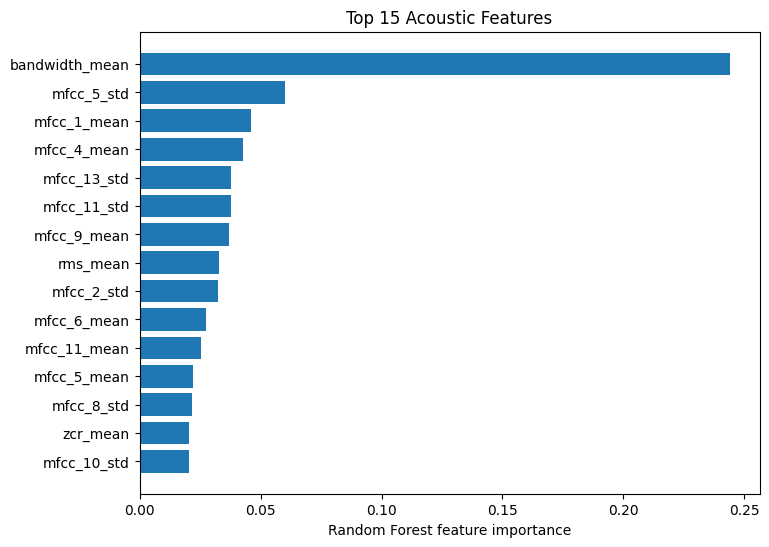

In [28]:
import matplotlib.pyplot as plt

top15 = feature_importance.head(15)

plt.figure(figsize=(8, 6))

plt.barh(
    top15["feature"][::-1],
    top15["importance"][::-1]
)

plt.xlabel("Random Forest feature importance")
plt.title("Top 15 Acoustic Features")

plt.show()